In [1]:
!pip install transformers
!pip install pillow pypdfium2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 42.4 MB/s eta 0:00:00


In [11]:
import torch
import requests
import json
import pprint
import matplotlib.pyplot as plt

from transformers import LightOnOcrForConditionalGeneration, LightOnOcrProcessor
from PIL import Image
from io import BytesIO
from bs4 import BeautifulSoup

In [4]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32 if device == "mps" else torch.bfloat16

model = LightOnOcrForConditionalGeneration.from_pretrained("lightonai/LightOnOCR-2-1B", torch_dtype=dtype).to(device)
processor = LightOnOcrProcessor.from_pretrained("lightonai/LightOnOCR-2-1B")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

You are using a model of type mistral3 to instantiate a model of type lighton_ocr. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/2.01G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/532 [00:00<?, ?it/s]

...

chat_template.jinja:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

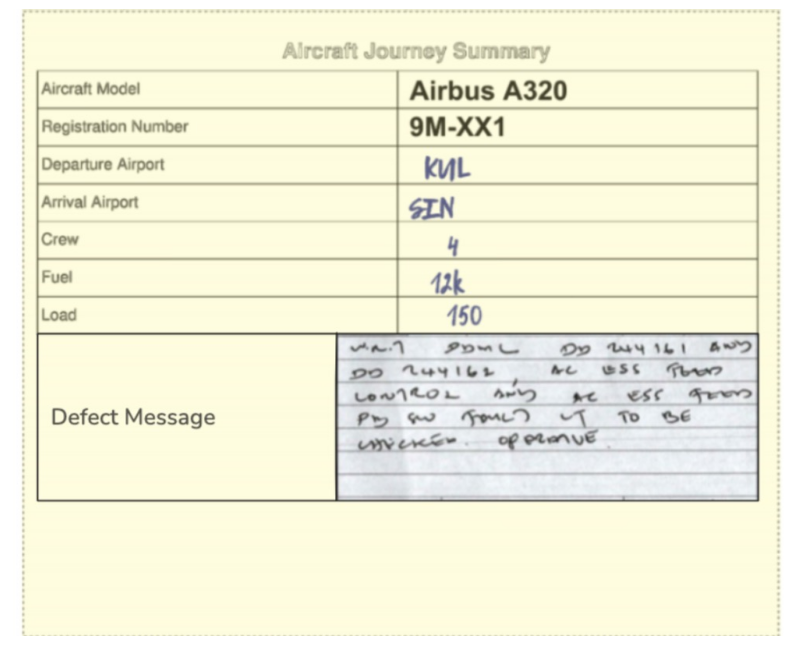

In [12]:
image_url = "https://raw.githubusercontent.com/yylam-ai/Aircraft-OCR/main/assets/aircraft_journey_summary.jpg"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

response = requests.get(image_url)
response.raise_for_status()

image = Image.open(BytesIO(response.content)).convert("RGB")


plt.figure(figsize=(10, 12))
plt.imshow(image)
plt.axis("off")
plt.show()

In [6]:
content = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image}
        ]
    }
]

# ===== PROCESS INPUT =====
inputs = processor.apply_chat_template(
    content,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

inputs = {
    k: v.to(device=device, dtype=dtype) if v.is_floating_point() else v.to(device)
    for k, v in inputs.items()
}

# ===== GENERATE OUTPUT =====
output_ids = model.generate(
    **inputs,
    max_new_tokens=1024
)

generated_ids = output_ids[0, inputs["input_ids"].shape[1]:]

output_text = processor.decode(
    generated_ids,
    skip_special_tokens=True
)

print(output_text)

# Aircraft Journey Summary

<table>
  <tr>
    <td>Aircraft Model</td>
    <td>Airbus A320</td>
  </tr>
  <tr>
    <td>Registration Number</td>
    <td>9M-XX1</td>
  </tr>
  <tr>
    <td>Departure Airport</td>
    <td>KVL</td>
  </tr>
  <tr>
    <td>Arrival Airport</td>
    <td>SIN</td>
  </tr>
  <tr>
    <td>Crew</td>
    <td>4</td>
  </tr>
  <tr>
    <td>Fuel</td>
    <td>12k</td>
  </tr>
  <tr>
    <td>Load</td>
    <td>150</td>
  </tr>
  <tr>
    <td>Defect Message</td>
    <td>var7 90ml DD 244161 and<br>DD 244162, AC 655 P200<br>CONTROL and AC 655 9000<br>PD 60 (F007) LT TO BE<br>UNCHECKED. OPERATE</td>
  </tr>
</table>


In [14]:
def parse_llm_table(html: str):
    soup = BeautifulSoup(html, "html.parser")

    # Default schema
    data = {
        "Aircraft Model": None,
        "Registration Number": None,
        "Departure Airport": None,
        "Arrival Airport": None,
        "Passenger": None,
        "Crew": None,
        "Fuel": None,
        "Load": None,
        "Defect Message": None,
    }

    for row in soup.find_all("tr"):
        cols = row.find_all("td")

        if len(cols) < 2:
            continue

        key = cols[0].get_text(strip=True)

        # Special handling for Defect Message
        if key.lower() == "defect message":
            pre = row.find("pre")
            if pre:
                value = pre.get_text("\n", strip=True)
            else:
                value = cols[1].get_text("\n", strip=True)
        else:
            value = cols[1].get_text(strip=True)

        data[key] = value

    # Add missing info list
    data["Missing Info"] = [
        key for key, value in data.items()
        if value is None
    ]

    return data


result = parse_llm_table(output_text)

pprint.pprint(result, indent=2)

{ 'Aircraft Model': 'Airbus A320',
  'Arrival Airport': 'SIN',
  'Crew': '4',
  'Defect Message': 'var7 90ml DD 244161 and\n'
                    'DD 244162, AC 655 P200\n'
                    'CONTROL and AC 655 9000\n'
                    'PD 60 (F007) LT TO BE\n'
                    'UNCHECKED. OPERATE',
  'Departure Airport': 'KVL',
  'Fuel': '12k',
  'Load': '150',
  'Missing Info': ['Passenger'],
  'Passenger': None,
  'Registration Number': '9M-XX1'}
